Generates 3A, FigS7

In [1]:
import numpy as np
import h5py
from scipy.io import loadmat
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from coding_model_fanofactor import *

## Plot 3A of example responses

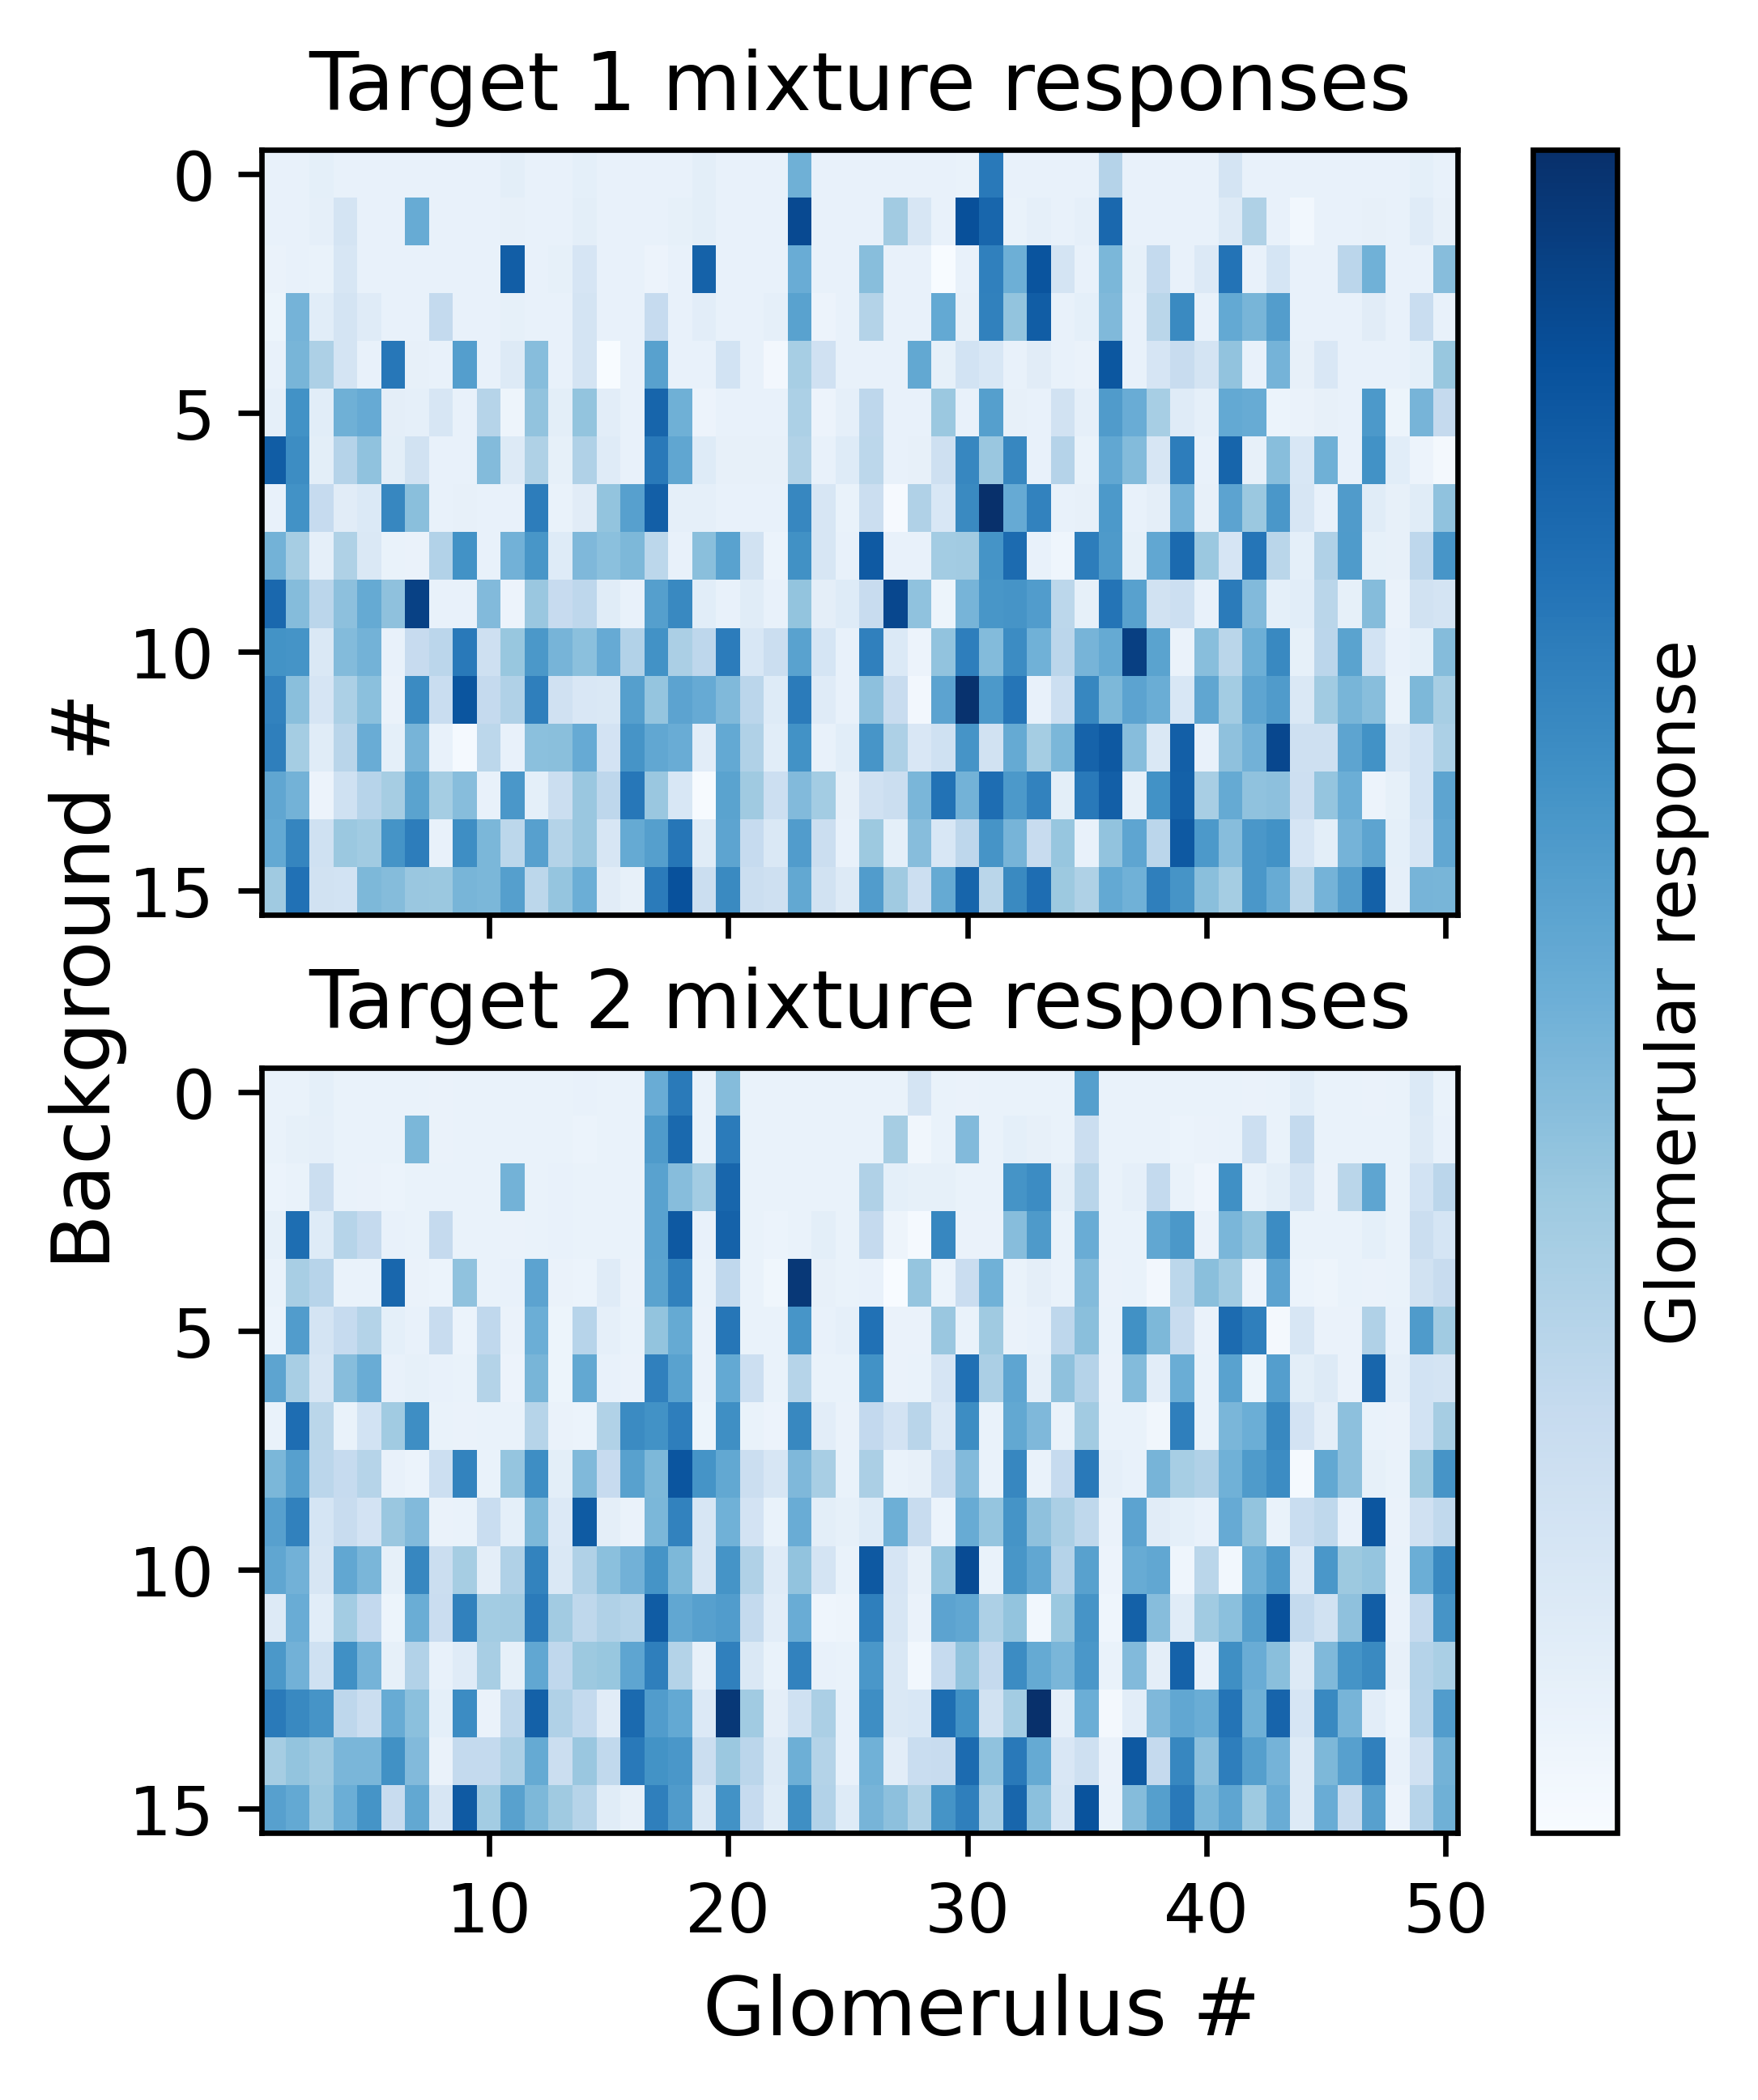

In [2]:
############################
# glomerular response model#
############################

N = 20 # N^2 ORNs
hill_n = 4 # Hill coef = 4 for the 4 cooperative CNG binding sites

rng = np.random.default_rng(seed=42)
# receptor parameters
rho = 0.5 #1.0 #0.5 # antagonism parameter (correlation between sensitivity and activation efficiency; see eq (22))
total_bg = 16 # total num of background odors
b = total_bg + 2 # number of odor slots (target + background)
lnkappa = rng.standard_normal((b,N,N)) # log kappa is normal
lneta = rng.standard_normal((b,N,N)) # log eta is normal
lneta = rho*lnkappa + np.sqrt(1 - rho*rho)*lneta # set the correlation; rho = 0 is fully antagonistic, rho = 1 is not at all antogonistic
lnkappa = -4*lnkappa
kappa = np.exp(lnkappa)
eta = np.exp(lneta)
n_samp = 10
n_cue_conc_levels = 10
cue_concs = np.logspace(-8, 8, n_cue_conc_levels) 
n_bg = 15
cue_conc = 1e-2
bg_conc = 3.16e-3
model_params = init_model_parameters(total_bg=16, bg_conc=bg_conc, train_cue_conc=cue_conc, seed=42)

F_max = 10.0
inv_kappa = 1.0 / kappa

n_glom_shown = 50
max_n_bg = 16
cue1_responses = []
cue2_responses = []

for n_bg in range(max_n_bg):
    concs1, _ = generate_odor_vecs_vectorized(
        n_samp, cue_conc, bg_conc, cue=0, n_bg=n_bg, total_bg=model_params["total_bg"]
    )
    concs2 = concs1.copy()
    concs2[:, 0] = 0.0
    concs2[:, 1] = cue_conc

    conc_tensor1 = tensorize_concs(concs1, n_samp, b, N)
    conc_tensor2 = tensorize_concs(concs2, n_samp, b, N)

    resp1 = compute_activity_vec(
        conc_tensor1, kappa, eta, F_max, hill_n, sigma=0.0, inv_kappa=inv_kappa, fano_factor_one=True, fano_factor=1.0
    )
    resp2 = compute_activity_vec(
        conc_tensor2, kappa, eta, F_max, hill_n, sigma=0.0, inv_kappa=inv_kappa, fano_factor_one=True, fano_factor=1.0
    )

    # first sample only
    r1 = resp1[0].ravel()[:n_glom_shown]
    r2 = resp2[0].ravel()[:n_glom_shown]
    cue1_responses.append(r1)
    cue2_responses.append(r2)

example_responses = np.concatenate((np.vstack(cue1_responses), np.vstack(cue2_responses)))

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(4, 4.5), dpi=600, sharex=True)
im = axes[0].imshow(example_responses[:16], cmap="Blues", aspect=2.0)
axes[1].imshow(example_responses[16:], cmap="Blues", aspect=2.0)
cbar = fig.colorbar(im, ax=axes, label="Glomerular response")
cbar.set_ticks([])

axes[0].set_title("Target 1 mixture responses")
axes[1].set_title("Target 2 mixture responses")
fig.supylabel("Background #")
fig.supxlabel("Glomerulus #")
yticks = np.arange(max_n_bg)[::5]#np.concatenate((np.arange(max_n_bg)[::5], np.arange(max_n_bg)[::5]))
axes[0].set_yticks(ticks=[0, 5, 10, 15], labels=yticks)
xticks = np.arange(10, n_glom_shown+1, 10)
axes[1].set_xticks(xticks - 1, labels=xticks)


## SI Fig 7: plot model and data sparsities all together

In [3]:
from scipy.io import loadmat
fname = '../data/Zak_2020/Glomerular_Matrix.mat'
resp = loadmat(fname)['Glomerular_Matrix']
burton = loadmat('../data/Burton_2022/Fig1figsupp3source data 1_figS3_data.mat')
burton_sparsities = burton['popsparseness_dF_F']

sparsity = population_sparsity(np.maximum(resp, 0))
burton_sorted_sparsity = sorted(burton_sparsities.flatten()[~np.isnan(burton_sparsities.flatten())], reverse=False)
burton_cum_frac = np.cumsum(burton_sorted_sparsity) / np.sum(burton_sorted_sparsity)

colors = [
    "#9d7dd0",
    "#5e78dd",    
    "#86d6d3",
    "#7dcc66",
    "#acd05b",
    "#efd962",
    "#dc9c4f",
    "#bd6f6d",
    "#c37ab4",
]
sns.set_palette(colors)


[0.00031623 0.00032833 0.00034089 0.00035393 0.00036747 0.00038152
 0.00039612 0.00041127 0.00042701 0.00044334 0.0004603  0.00047791
 0.00049619 0.00051518 0.00053489 0.00055535 0.00057659 0.00059865
 0.00062155 0.00064533 0.00067002 0.00069565 0.00072226 0.00074989
 0.00077858 0.00080837 0.00083929 0.0008714  0.00090474 0.00093935
 0.00097528 0.00101259 0.00105133 0.00109155 0.00113331 0.00117666
 0.00122168 0.00126841 0.00131694 0.00136732 0.00141963 0.00147393
 0.00153032 0.00158886 0.00164965 0.00171276 0.00177828 0.00184631
 0.00191694 0.00199027 0.00206641 0.00214547 0.00222754 0.00231276
 0.00240124 0.0024931  0.00258847 0.0026875  0.00279031 0.00289705
 0.00300788 0.00312295 0.00324242 0.00336646 0.00349525 0.00362896
 0.00376779 0.00391193 0.00406159 0.00421697 0.00437829 0.00454578
 0.00471969 0.00490024 0.0050877  0.00528234 0.00548442 0.00569423
 0.00591206 0.00613823 0.00637306 0.00661686 0.00687    0.00713281
 0.00740568 0.00768899 0.00798314 0.00828854 0.00860563 0.0089

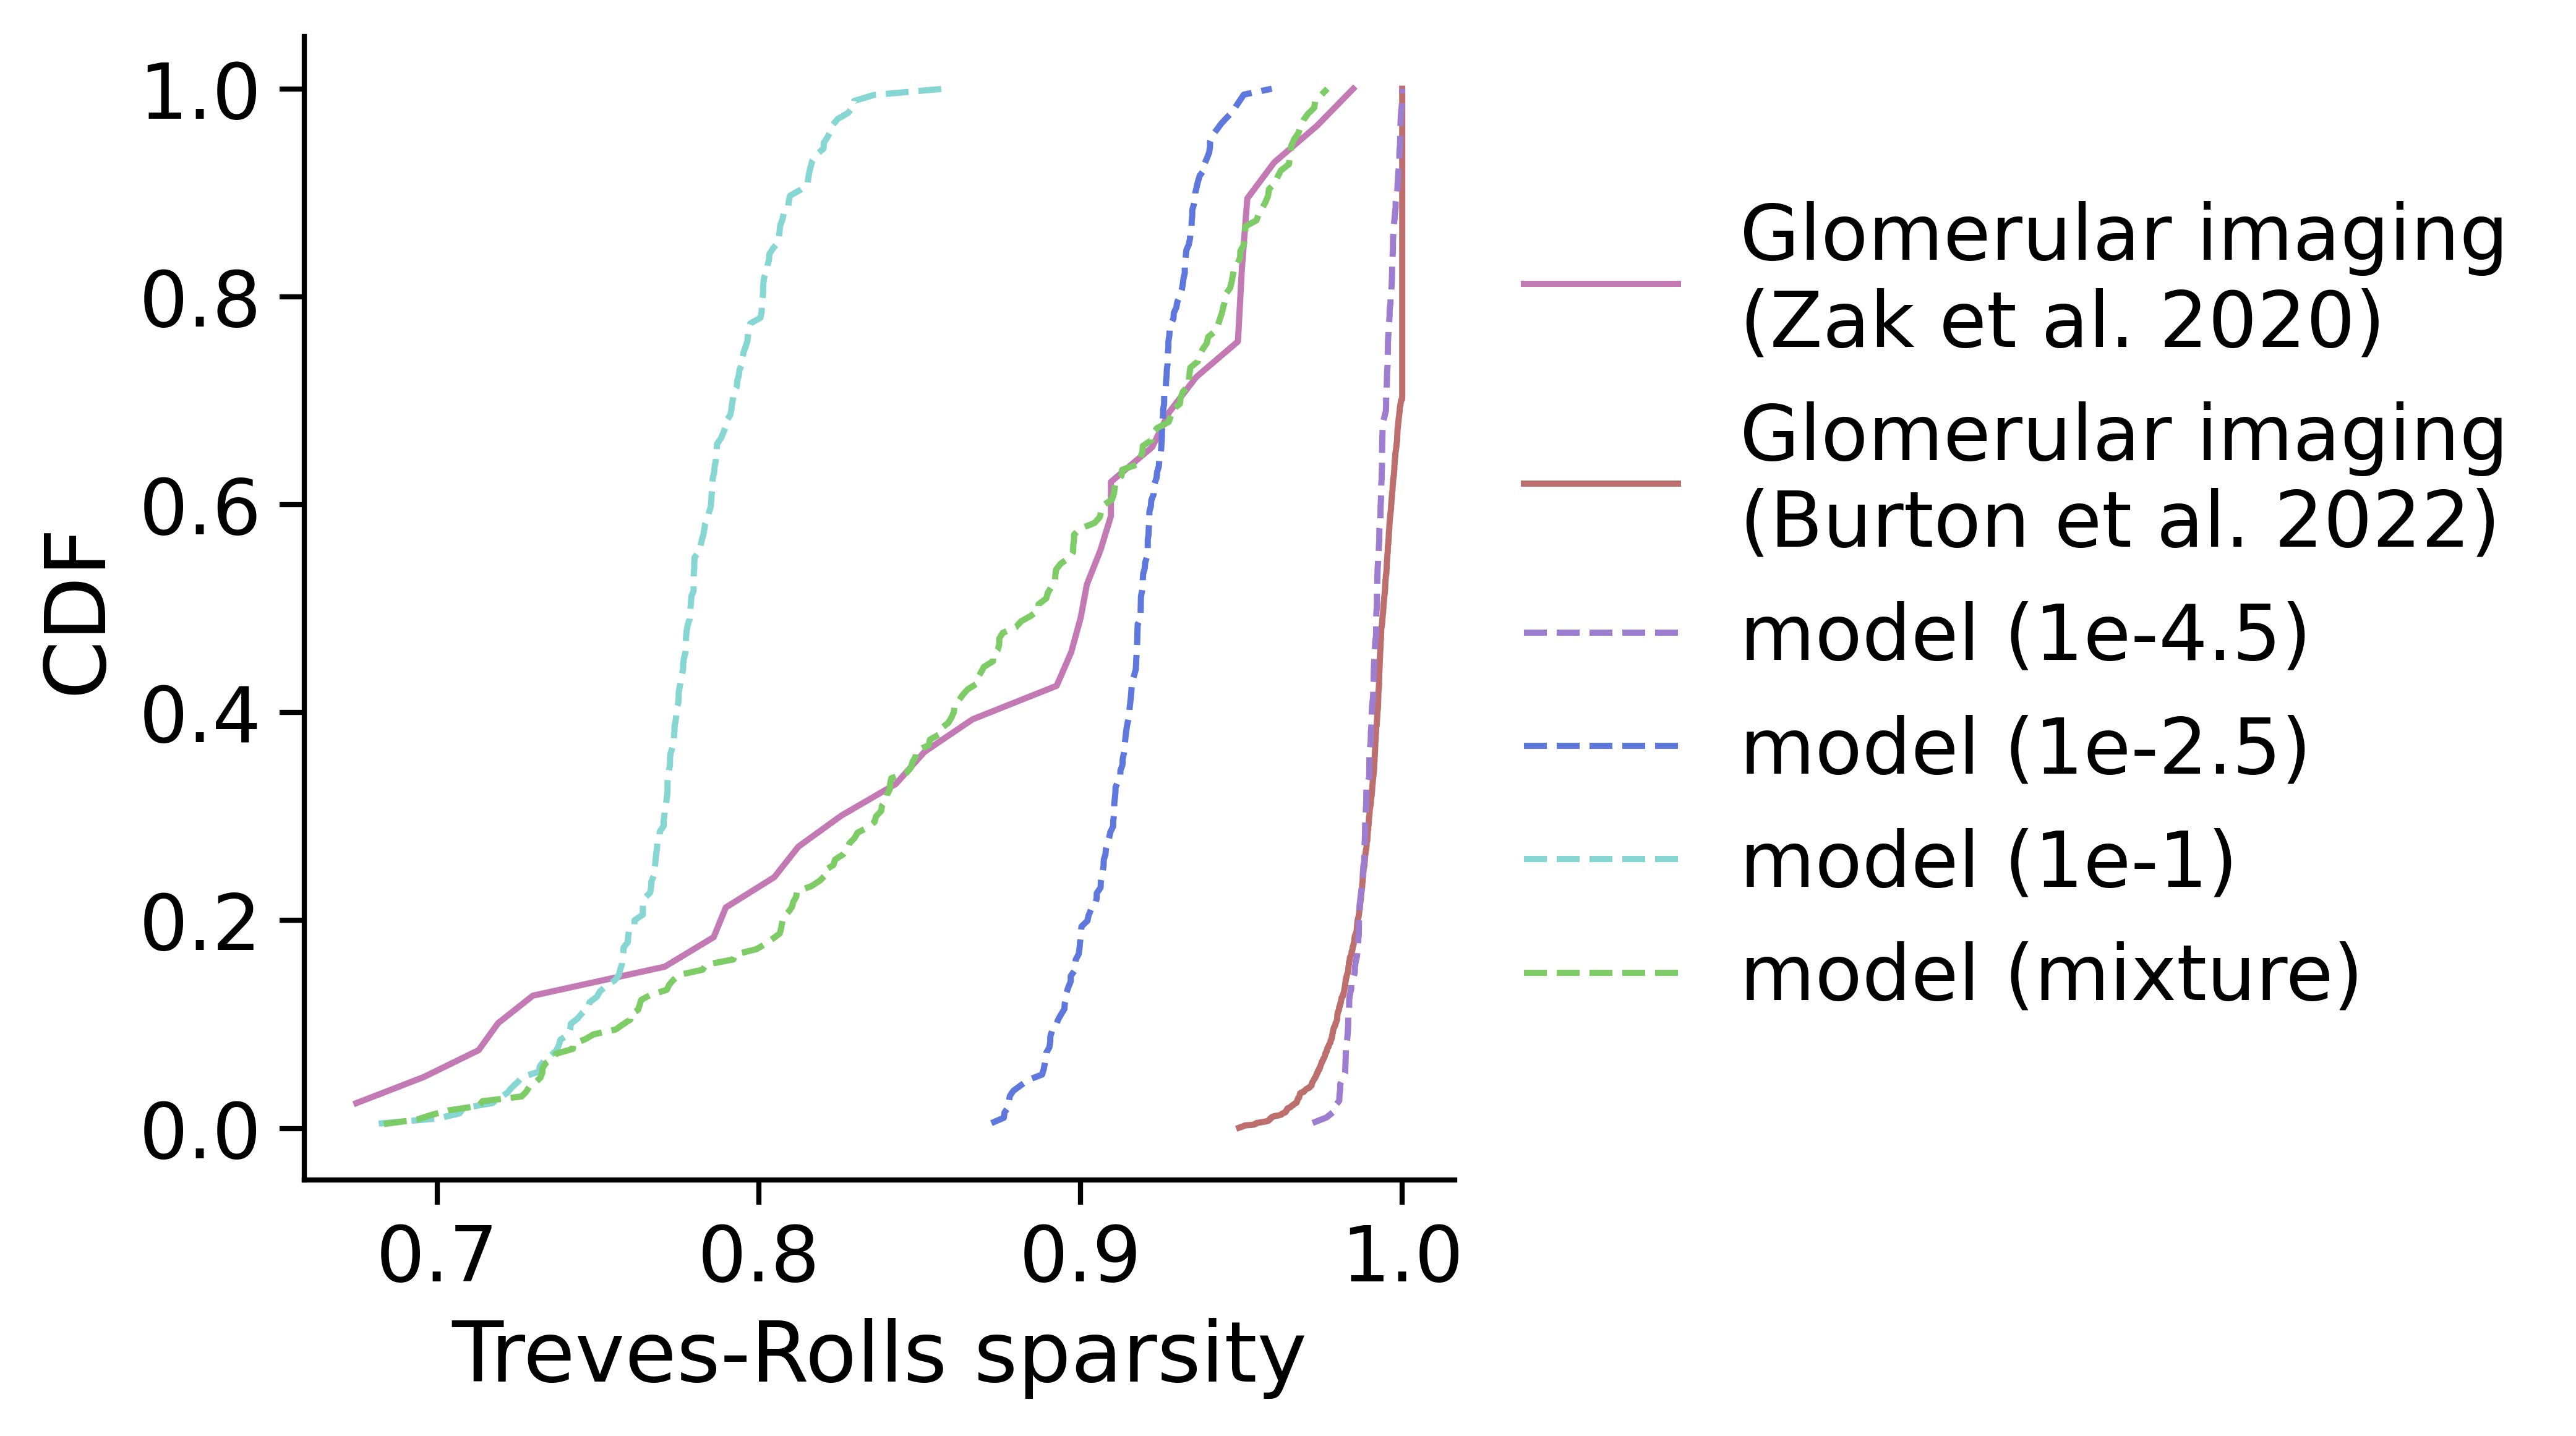

In [4]:

N = 20
rho = 0.5
rng = np.random.default_rng(42)
# compute population sparsity for 32 single odors
conc = 3.2e-3 #1e-3 # 1e0 # 1e-3 is weak, 1e0 is strong
n_glom_shown = 228
b = 185  # number of single odors/channels
sns.set_context("paper", font_scale=1.7)  # "talk", "notebook", "paper", "poster"

def glom_model_sparsity(conc, n_glom_shown=228, b=185, concs=None):
    if concs is None:
        concs = np.eye(b) * conc
    conc_tensor = tensorize_concs(concs, n_samp=concs.shape[0], b=concs.shape[1], N=N)

    rng = np.random.default_rng(42)
    lnkappa = rng.standard_normal((b, N, N))
    lneta = rng.standard_normal((b, N, N))
    lneta = rho * lnkappa + np.sqrt(1 - rho * rho) * lneta
    lnkappa = -4 * lnkappa
    kappa = np.exp(lnkappa)
    eta = np.exp(lneta)

    inv_kappa = 1.0 / kappa
    F_max = 10.0
    hill_n = 4

    r = compute_activity_vec(
    conc_tensor,
    kappa,
    eta,
    F_max=F_max,
    n=hill_n,
    sigma=0.4 / np.sqrt(5), # average over 5 trials
    inv_kappa=inv_kappa,
    fano_factor_one=True,
    fano_factor=1.0,
    ).reshape(concs.shape[0], -1)[:, :n_glom_shown]

    r = np.maximum(r, 0) # non-negative
    model_sorted_sparsity = sorted(population_sparsity(r.T), reverse=False)
    # print(len(model_sorted_sparsity))
    model_cum_frac = np.cumsum(model_sorted_sparsity) / np.sum(model_sorted_sparsity)
    return model_sorted_sparsity, model_cum_frac

weak_sparsity, weak_cdf = glom_model_sparsity(3.2e-3)
very_weak_sparsity, very_weak_cdf = glom_model_sparsity(10**(-4.5))
strong_sparsity, strong_cdf = glom_model_sparsity(0.1)
mixture_sparsity, mixture_cdf = glom_model_sparsity(conc=0, concs=np.diag(np.logspace(-3.5, -0.5, b)))

print(np.logspace(-3.5, -0.5, b))


plt.figure(figsize=(4,4), dpi=600)
sorted_sparsity = np.sort(sparsity)
cum_frac = np.cumsum(sorted_sparsity) / sorted_sparsity.sum()

plt.plot(sorted_sparsity, cum_frac, color='C8', label="Glomerular imaging\n(Zak et al. 2020)")
plt.plot(burton_sorted_sparsity, burton_cum_frac, color='C7', label="Glomerular imaging\n(Burton et al. 2022)")
plt.plot(very_weak_sparsity, very_weak_cdf, linestyle='--', label="model (1e-4.5)")
plt.plot(weak_sparsity, weak_cdf, linestyle='--', label="model (1e-2.5)")
plt.plot(strong_sparsity, strong_cdf, linestyle='--', label="model (1e-1)")
plt.plot(mixture_sparsity, mixture_cdf, linestyle='--', label="model (mixture)")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.xlabel('Treves-Rolls sparsity')
plt.ylabel('CDF')
# plt.title('Fano factor = 1 noise')
# plt.xlim(0.5, 1.)
sns.despine()
plt.savefig('../figures/manuscript/glomerular_data_sparsity_cdf.svg', dpi=600, bbox_inches='tight')
plt.savefig('../figures/manuscript/glomerular_data_sparsity_cdf.png', dpi=600, bbox_inches='tight')